# DB Fernverkehr — Historical Delay Analysis

Offline analysis of the realtime history collected by `python -m dbrt`, covering the
four analyses named in `architecture.md`:

1. **Train punctuality** — against DB's own <6-minute definition
2. **Station-level delay** — where the network loses time
3. **Delay propagation** — how delay accumulates along a route
4. **Route reliability** — which products and corridors hold their schedule

The final section trains the delay-prediction model and checks it against a persistence baseline.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from dbrt import analytics
from dbrt.config import Settings
from dbrt.storage import Warehouse

sns.set_theme(style="darkgrid", palette="rocket")
plt.rcParams.update({"figure.figsize": (11, 4.5), "figure.dpi": 110, "axes.titleweight": "600"})

warehouse = Warehouse(Settings.from_env().dsn())
print(f"{warehouse.count('stop_time_updates'):,} stop-time observations stored")

58,977 stop-time observations stored


## 1. Punctuality

Deutsche Bahn counts a stop as punctual when it is less than 6 minutes late.

In [2]:
summary = analytics.punctuality(warehouse)
pd.Series(summary).to_frame("value")

,value
total_stops,1567.00
punctual_stops,1222.00
punctuality_pct,77.98
mean_delay_seconds,316.50
max_delay_seconds,5460.00
trips,148.00
threshold_seconds,360.00


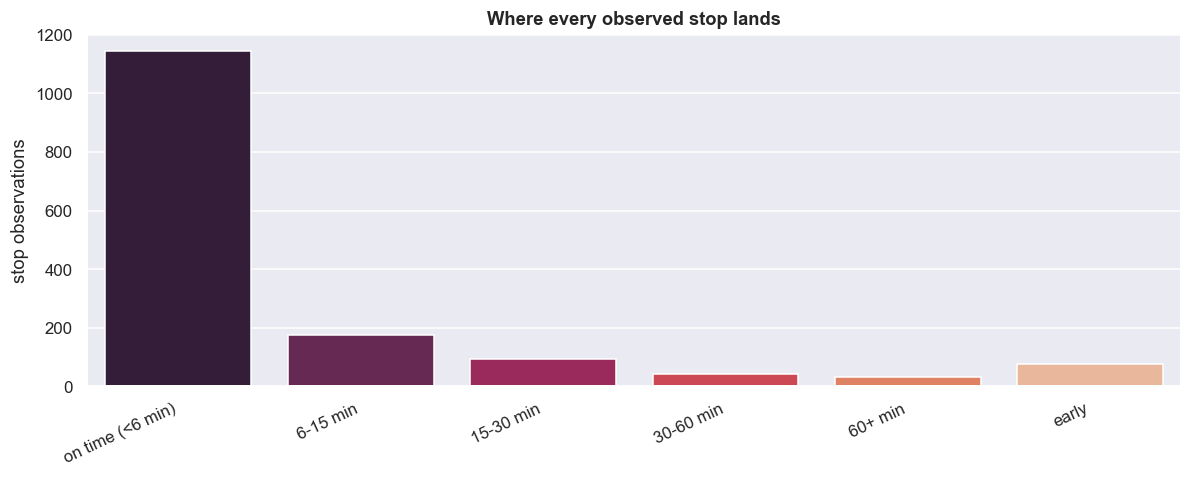

In [3]:
distribution = pd.DataFrame(analytics.delay_distribution(warehouse))
ax = sns.barplot(distribution, x="band", y="stops", hue="band", legend=False)
ax.set(title="Where every observed stop lands", xlabel="", ylabel="stop observations")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

## 2. Station-level delay

Stations ranked by mean delay, filtered to those with enough observations to be meaningful.

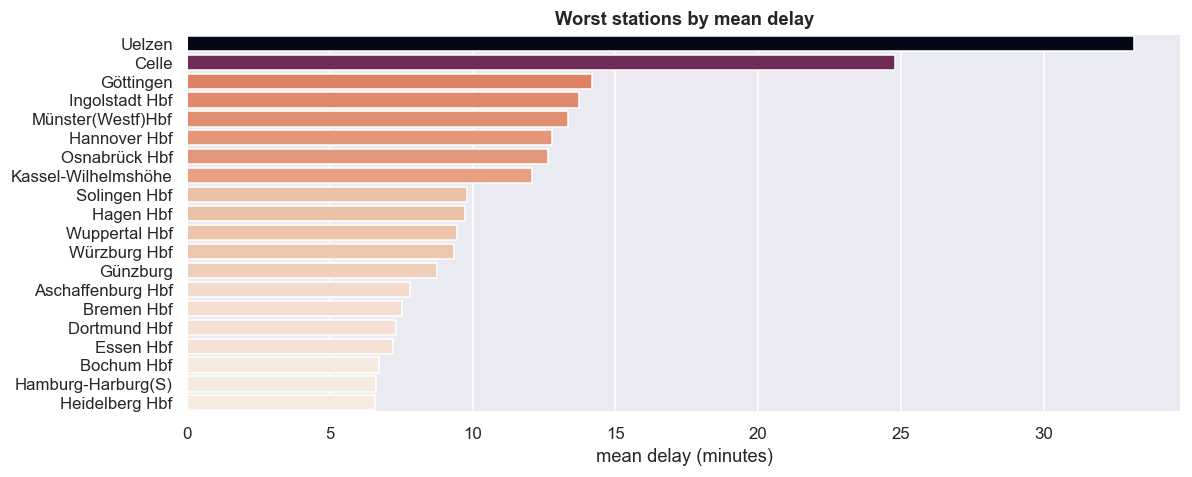

,stop_name,observations,mean_delay_min,punctuality_pct
0,Uelzen,6,33.166667,50.0
1,Celle,5,24.800000,40.0
2,Göttingen,27,14.185000,59.3
3,Ingolstadt Hbf,14,13.715000,64.3
4,Münster(Westf)Hbf,18,13.333333,22.2
5,Hannover Hbf,33,12.788333,60.6
6,Osnabrück Hbf,14,12.643333,28.6
7,Kassel-Wilhelmshöhe,27,12.073333,66.7
8,Solingen Hbf,10,9.800000,70.0
9,Hagen Hbf,11,9.726667,63.6


In [4]:
stations = pd.DataFrame(analytics.station_delays(warehouse, limit=20, min_observations=5))
stations["mean_delay_min"] = stations["mean_delay_seconds"] / 60

ax = sns.barplot(stations, y="stop_name", x="mean_delay_min", hue="mean_delay_min",
                 palette="rocket_r", legend=False)
ax.set(title="Worst stations by mean delay", xlabel="mean delay (minutes)", ylabel="")
plt.tight_layout(); plt.show()
stations[["stop_name", "observations", "mean_delay_min", "punctuality_pct"]].head(10)

## 3. Delay propagation

How a single service accumulates delay along its route. This is the relationship the ML model learns.

In [5]:
worst = pd.DataFrame(analytics.worst_trips(warehouse, limit=5))
worst

,trip_id,service_date,route_category,max_delay_seconds,mean_delay_seconds,stops,route_name
0,1316498,2026-08-18,ICE,5460,3102.9,7,ICE 20
1,1116018,2026-08-18,ICE,4500,3060.0,9,ICE 25
2,1759011,2026-08-18,ICE,4440,3495.0,12,ICE 41
3,1663292,2026-08-17,ICE,4320,2568.6,21,ICE 42
4,1418933,2026-08-17,ICE,4260,2083.6,11,ICE 25


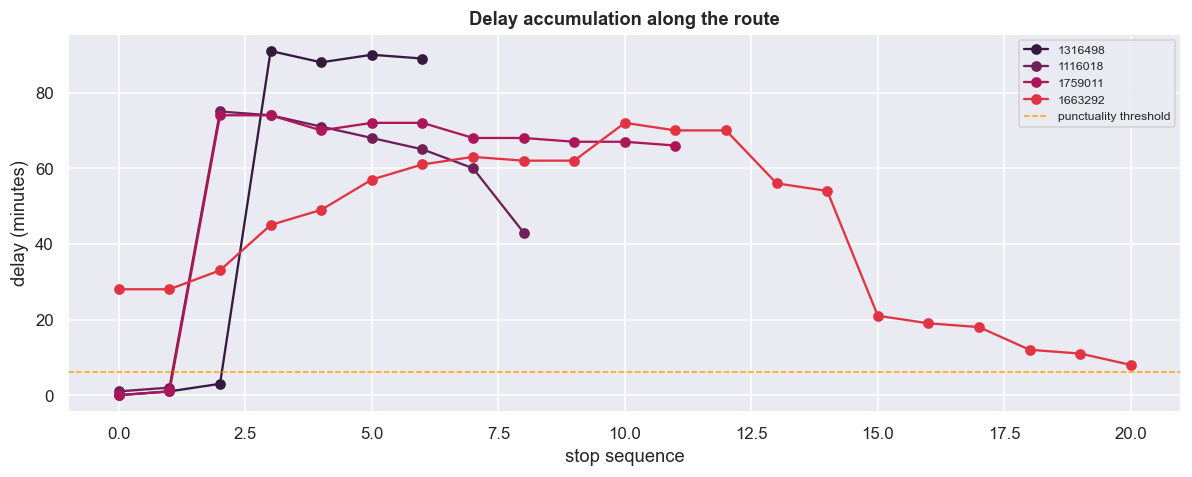

In [6]:
fig, ax = plt.subplots()
for trip_id in worst["trip_id"].head(4):
    route = pd.DataFrame(analytics.delay_propagation(warehouse, trip_id))
    if route.empty:
        continue
    delay = route["arrival_delay"].fillna(route["departure_delay"]) / 60
    ax.plot(route["stop_sequence"], delay, marker="o", label=trip_id)

ax.axhline(6, ls="--", c="orange", lw=1, label="punctuality threshold")
ax.set(title="Delay accumulation along the route", xlabel="stop sequence", ylabel="delay (minutes)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Route reliability by product

ICE, IC, EC and ECE compared on punctuality and mean delay.

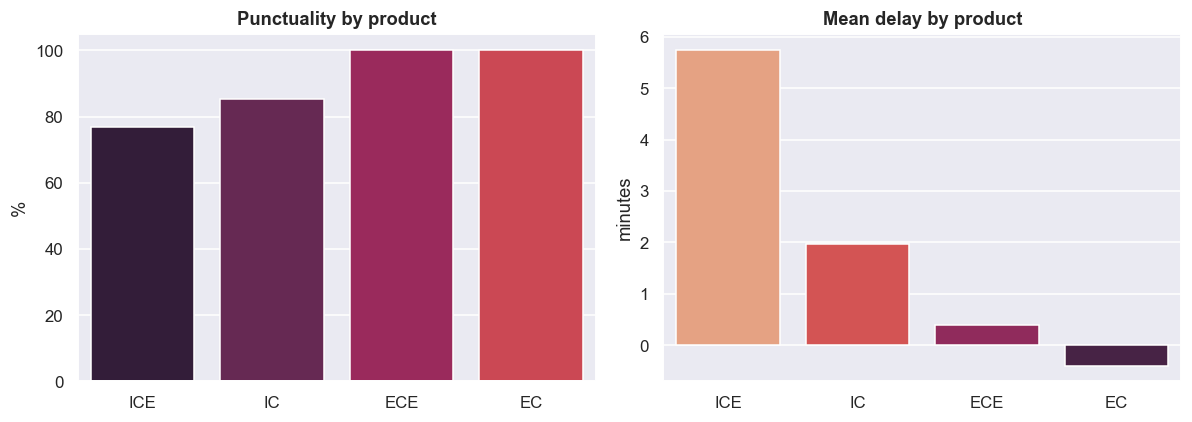

,route_category,trips,stops,mean_delay_seconds,punctuality_pct,mean_delay_min
0,ICE,130,1381,345.0,76.8,5.750000
1,IC,15,163,118.2,85.3,1.970000
2,ECE,2,18,23.3,100.0,0.388333
3,EC,1,5,-24.0,100.0,-0.400000


In [7]:
categories = pd.DataFrame(analytics.category_breakdown(warehouse))
categories["mean_delay_min"] = categories["mean_delay_seconds"] / 60

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(categories, x="route_category", y="punctuality_pct", hue="route_category",
            legend=False, ax=left).set(title="Punctuality by product", xlabel="", ylabel="%")
sns.barplot(categories, x="route_category", y="mean_delay_min", hue="route_category",
            palette="rocket_r", legend=False, ax=right).set(
    title="Mean delay by product", xlabel="", ylabel="minutes")
plt.tight_layout(); plt.show()
categories

## 5. Time series

The network's delay profile over the collection window — the same series the live dashboard animates.

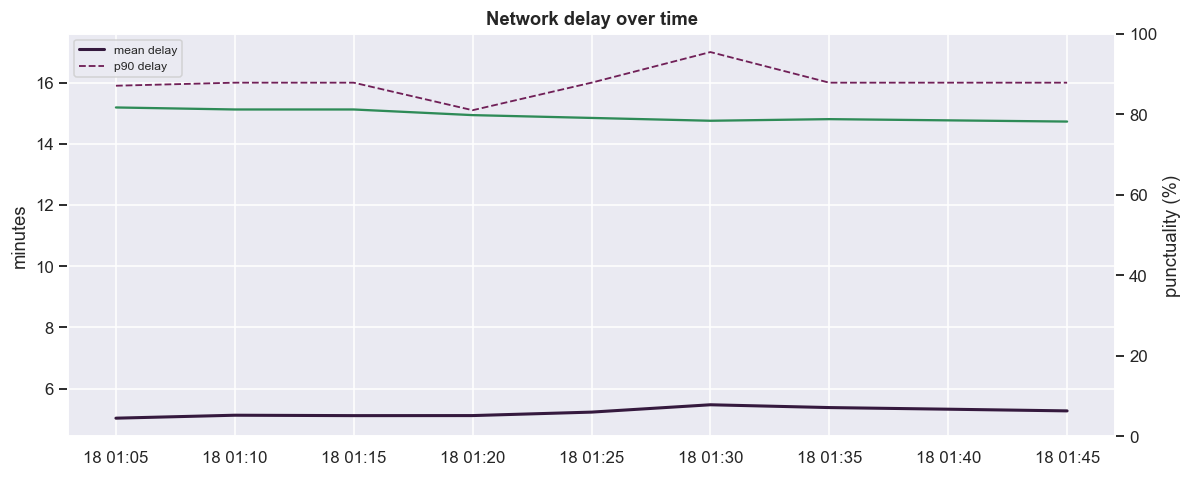

In [8]:
series = pd.DataFrame(analytics.delay_timeseries(warehouse, bucket_minutes=5, hours=24))
series["bucket"] = pd.to_datetime(series["bucket"])

fig, ax = plt.subplots()
ax.plot(series["bucket"], series["mean_delay_seconds"] / 60, lw=2, label="mean delay")
ax.plot(series["bucket"], series["p90_delay_seconds"] / 60, lw=1.2, ls="--", label="p90 delay")
ax.set(title="Network delay over time", xlabel="", ylabel="minutes")

punctuality = ax.twinx()
punctuality.plot(series["bucket"], series["punctuality_pct"], c="seagreen", lw=1.5, label="punctuality")
punctuality.set_ylabel("punctuality (%)"); punctuality.set_ylim(0, 100); punctuality.grid(False)

ax.legend(loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

## 6. Disruptions

Skipped station calls, which GTFS-RT reports separately from delay.

In [9]:
print(analytics.cancellations(warehouse))
pd.DataFrame(analytics.skipped_stations(warehouse, limit=10))

{'skipped_stops': 30, 'affected_trips': 11, 'cancelled_trips': 0, 'total_stops': 1597, 'skipped_pct': 1.88}


,stop_name,stop_id,skipped
0,Frankfurt(Main)Hbf,540068,83
1,Augsburg Hbf,284993,80
2,München Hbf,137919,80
3,München-Pasing,279743,80
4,Köln Hbf,452576,74
5,Celle,629922,40
6,Darmstadt Hbf,153377,40
7,Donauwörth,5905,40
8,Frankfurt(M) Flughafen Fernbf,280095,40
9,Günzburg,409443,40


## 7. Delay prediction

Given that a train is *N* seconds late at its current stop, how late will it be at the next one?

The benchmark is **persistence** — assume the delay carries over unchanged. On live data 55% of
stop-to-stop deltas are exactly zero, which makes that a strong baseline; the model has to beat it
to be worth anything.

In [10]:
from dbrt.ml import DelayModel, load_history, next_stop_pairs

history = load_history(warehouse)
pairs = next_stop_pairs(history)
print(f"{len(history):,} observations -> {len(pairs):,} training pairs")

delta = pairs["next_delay"] - pairs["delay"]
print(f"delta: median {delta.median():.0f}s, {100 * (delta == 0).mean():.1f}% exactly unchanged")

1,567 observations -> 1,419 training pairs
delta: median 0s, 48.2% exactly unchanged


In [11]:
model = DelayModel()
metrics = model.train(history)
pd.Series({k: v for k, v in metrics.items() if k != "features"}).to_frame("value")

,value
samples,1419.0
cv_folds,5.0
mae_seconds,114.0
mae_std_seconds,12.6
baseline_mae_seconds,117.8
rmse_seconds,340.0
baseline_rmse_seconds,341.4
improvement_pct,3.3


Model MAE 114.0s beats persistence at 117.8s (+3.3%)


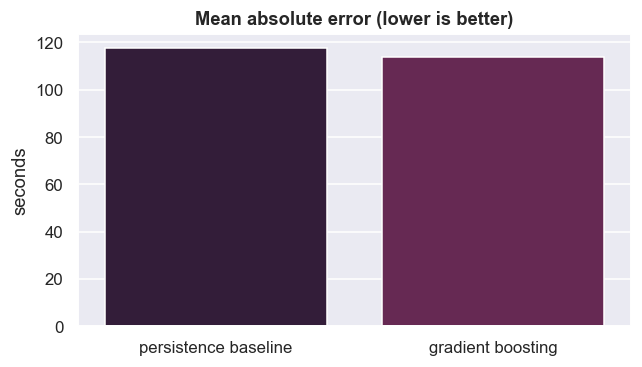

In [12]:
verdict = "beats" if metrics["improvement_pct"] > 0 else "does not beat"
print(f"Model MAE {metrics['mae_seconds']}s {verdict} persistence at {metrics['baseline_mae_seconds']}s "
      f"({metrics['improvement_pct']:+.1f}%)")

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=["persistence baseline", "gradient boosting"],
            y=[metrics["baseline_mae_seconds"], metrics["mae_seconds"]],
            hue=["persistence baseline", "gradient boosting"], legend=False, ax=ax)
ax.set(title="Mean absolute error (lower is better)", ylabel="seconds")
plt.tight_layout(); plt.show()